In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import torch.nn as nn

In [3]:
X = torch.linspace(1,50,50).reshape(-1,1)

In [6]:
torch.manual_seed(71)
e = torch.randint(-8,9,(50,1),dtype=torch.float)
# print(e)

In [7]:
y = 2*X + 1 + e

In [8]:
y.shape

torch.Size([50, 1])

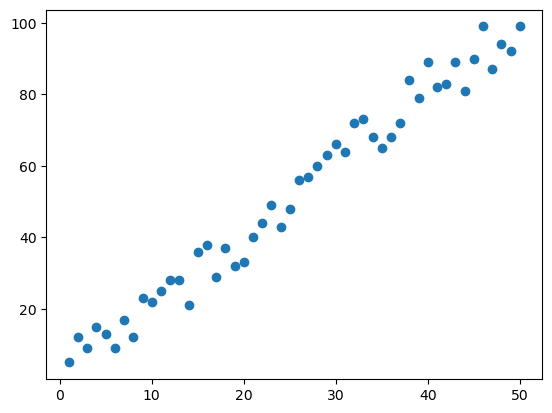

In [10]:
plt.scatter(X.numpy(),y.numpy())

In [11]:
torch.manual_seed(59)
model = nn.Linear(in_features=1,out_features=1)
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [12]:
class Model(nn.Module):
    def __init__(self,in_features,out_features):
        super().__init__()
        self.linear = nn.Linear(in_features,out_features)
    def forward(self,x):
        y_pred = self.linear(x)
        return y_pred

In [14]:
torch.manual_seed(59)
model = Model(1,1)
print(f'weight {model.linear.weight}')
print(f'Bias {model.linear.bias}')

weight Parameter containing:
tensor([[0.1060]], requires_grad=True)
Bias Parameter containing:
tensor([0.9638], requires_grad=True)


In [18]:
for name,param in model.named_parameters():
    print(name,'\t',param.item())

linear.weight 	 0.10597813129425049
linear.bias 	 0.9637961387634277


In [20]:
x = torch.tensor([2.0])
print(model.forward(x))

tensor([1.1758], grad_fn=<ViewBackward0>)


In [25]:
x1 = np.linspace(0.0,50.0,50)

In [27]:
w1 = 0.10597813129425049
b1 = 0.9637961387634277

y1 = w1*x1 + b1

In [29]:
y1

array([0.96379614, 1.07193709, 1.18007804, 1.28821899, 1.39635994,
       1.50450089, 1.61264184, 1.72078279, 1.82892374, 1.93706469,
       2.04520564, 2.15334659, 2.26148754, 2.36962849, 2.47776944,
       2.58591039, 2.69405134, 2.80219229, 2.91033324, 3.01847419,
       3.12661514, 3.2347561 , 3.34289705, 3.451038  , 3.55917895,
       3.6673199 , 3.77546085, 3.8836018 , 3.99174275, 4.0998837 ,
       4.20802465, 4.3161656 , 4.42430655, 4.5324475 , 4.64058845,
       4.7487294 , 4.85687035, 4.9650113 , 5.07315225, 5.1812932 ,
       5.28943415, 5.3975751 , 5.50571605, 5.613857  , 5.72199795,
       5.8301389 , 5.93827985, 6.0464208 , 6.15456175, 6.2627027 ])

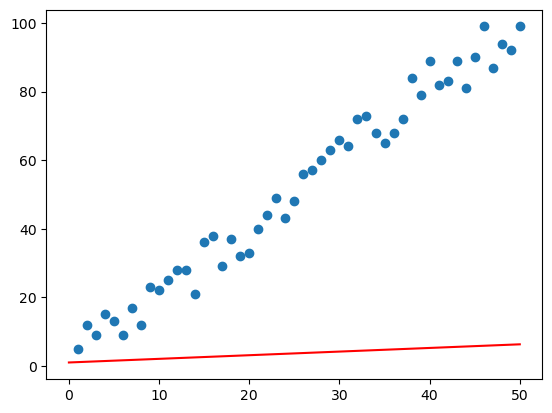

In [33]:
plt.plot(x1,y1,'r')
plt.scatter(X.numpy(),y.numpy())

In [34]:
criterion = nn.MSELoss()

In [35]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.001)

In [38]:
epochs = 50

losses = []

for i in range(epochs):
    i = i+1
    y_pred = model.forward(X)
    loss = criterion(y_pred,y)

    losses.append(loss)
    print(f'epoches {i} loss: {loss.item()} weight: {model.linear.weight.item()} bias: {model.linear.bias.item()}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

epoches 1 loss: 3057.216796875 weight: 0.10597813129425049 bias: 0.9637961387634277
epoches 2 loss: 1588.5311279296875 weight: 3.334900379180908 bias: 1.0604636669158936
epoches 3 loss: 830.2999877929688 weight: 1.0148327350616455 bias: 0.9922628402709961
epoches 4 loss: 438.8524169921875 weight: 2.6817996501922607 bias: 1.0425218343734741
epoches 5 loss: 236.7615203857422 weight: 1.4840211868286133 bias: 1.0076650381088257
epoches 6 loss: 132.4291229248047 weight: 2.3446059226989746 bias: 1.0339646339416504
epoches 7 loss: 78.56572723388672 weight: 1.7262253761291504 bias: 1.0163217782974243
epoches 8 loss: 50.75775909423828 weight: 2.170504093170166 bias: 1.0302516222000122
epoches 9 loss: 36.4012565612793 weight: 1.851245641708374 bias: 1.0214954614639282
epoches 10 loss: 28.989229202270508 weight: 2.0806007385253906 bias: 1.029038906097412
epoches 11 loss: 25.162382125854492 weight: 1.9157683849334717 bias: 1.0248701572418213
epoches 12 loss: 23.186473846435547 weight: 2.0341656208